# ATLAS Dijet Spectrum

This notebook reproduces the ATLAS Run 2 dijet example used in the paper. It prepares the public HEPData spectrum as a binned RooFit dataset, compares the standard dijet background function with finite exponential mixtures, and studies model order using repeated likelihood fits.

## Roadmap

1. Load the ATLAS histogram and define a RooFit observable with the published binning.
2. Fit exponential mixtures with several component counts using randomized restarts; results are cached under `cache/fits/`.
3. Compare AIC and BIC across successful fits, then plot the selected mixture alongside the dijet function.

The batch-execution cell can submit to HTCondor. Set `remake` deliberately: cached fit payloads are reused when it is `False`.

In [1]:
# Imports
import ROOT
import array

from tools import scale_out as so
from tools import storage as stor

from emm import data
from emm import fitting
from emm import models
from emm import plotting

import matplotlib.pyplot as plt
import numpy as np

figures_cache = stor.ensure_cache("figures")

Welcome to JupyROOT 6.30/04


In [2]:
# Load the data
h_obs, h_fit = data.get_dijet_data()
print(f"h_obs integral: {h_obs.Integral()}, h_fit integral: {h_fit.Integral()}")

h_obs integral: 28619185.0, h_fit integral: 28619309.650748283


In [8]:
# Get binning from data
xaxis = h_obs.GetXaxis()
boundaries = [xaxis.GetBinLowEdge(i) for i in range(1, xaxis.GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))

x = ROOT.RooRealVar("x", "Dijet Mass [GeV]", boundaries[0], boundaries[-1])
x.setBinning(binning)

dijet_data = ROOT.RooDataHist("ATLAS_dijet_data", "ATLAS dijet data", ROOT.RooArgList(x), h_obs)
data_mean = dijet_data.mean(x)

print(f"Data mean: {data_mean}")

# SW -- Dijet Paper Fit
dh_fit = ROOT.RooDataHist("dh_fit", "dh_fit", ROOT.RooArgList(x), h_fit)
pdf_fit = ROOT.RooHistPdf("pdf_fit", "pdf_fit", ROOT.RooArgSet(x), dh_fit)

fit_options = [
    ROOT.RooFit.PrintLevel(-1),
    ROOT.RooFit.IntegrateBins(1e-4),
    ROOT.RooFit.Offset(True),
    ROOT.RooFit.Strategy(2),
    # ROOT.RooFit.Range("fit_range")
]

Data mean: 1347.5082817871998


In [13]:
# Test fitting
# model_primitive = models.ModelPrimitive(
#     models.ExponentialMixtureModel,
#     4, data_mean=dijet_data.mean(x), name="ExponentialMixtureModel-4"
# )
# fit_result = fitting.fit_random_restarts(
#     x, dijet_data, model_primitive,
#     seed=42, n_restarts=100, n_retries=30,
#     fit_options=fit_options,
#     print_level=4,
#     save=False,
#     return_all_results=True,
#     use_multiprocessing=True,
# )


## Model Selection

Each `ModelPrimitive` records how to instantiate one candidate mixture order. The next cells launch independent randomized-restart fits, serialize every successful minimum, and then select the lowest negative log-likelihood for each order. AIC and BIC use $2k - 1$ free mixture parameters for a $k$-component model.

In [23]:
# Configuration
model_primitives = [
    models.ModelPrimitive(
        models.ExponentialMixtureModel,
        k,
        data_mean=data_mean,
        name=f"ExponentialMixture-{k}"
    ) for k in range(2, 7)
]

seed = 42
n_random_restarts = 50
n_retries = 30

# Test overrides
# n_random_restarts = 10
# n_retries = 10

In [ ]:
# Run jobs
import os

# remake = False
remake = True

tasks = []
for mp in model_primitives:
    
    filename = fitting.random_restarts_filename(
        mp.name,
        dijet_data.GetName(),
        n_random_restarts,
        seed,
    )
    if os.path.exists(filename):
        if remake:
            print(f"File {filename} will be remade.")
            os.remove(filename)
        else:
            print(f"File {filename} already exists. Skipping {mp.name}.")
            continue
    print(f"Adding task for model {mp.name}")
    task = so.Task(
        fitting.fit_random_restarts,
        x, dijet_data, mp,
        seed, n_random_restarts,
        n_retries=n_retries,
        save=True,
        fit_options=fit_options,
        print_level=4
    )
    tasks.append(task)

_ = so.run_tasks(
    tasks,
    use_condor=True,
    condor_job_name="emm_model_selection_dijet",
    env_wrapper=so.run_in_mamba,
)

Adding task for model ExponentialMixture-2
Adding task for model ExponentialMixture-3
Adding task for model ExponentialMixture-4
Adding task for model ExponentialMixture-5
Adding task for model ExponentialMixture-6
Submitting 5 tasks to condor with job name 'emm_model_selection_dijet'


In [36]:
# Load fit results
import pickle
import os

results = {}
for mp in model_primitives:
    name = mp.name
    k = int(name.split("-")[-1])

    filename = fitting.random_restarts_filename(
        mp.name,
        dijet_data.GetName(),
        n_random_restarts,
        seed,
    )
    if not os.path.exists(filename):
        print(f"File {filename} does not exist. Skipping.")
        continue
    with open(filename, 'rb') as f:
        fit_result = pickle.load(f)
    results[k] = fit_result
    # print(f"Printing result for k={k}")
    # for res in fit_result:
    #     print(res["nll"])

[{'status': 0, 'nll': 186084302.7789362, 'initial_pars': {'raw_rate_0': 1.2969232684089564, 'raw_rate_1': 2.625065190057543, 'raw_rate_2': 14.565557358625428, '_raw_weight_1': -2.3910408906907796, '_raw_weight_2': -4.158099790190091}, 'final_pars': {'raw_rate_0': 1.8046283709556536, 'raw_rate_1': 0.5370494906233841, 'raw_rate_2': 0.981566858292975, '_raw_weight_1': -0.7653054318266787, '_raw_weight_2': 0.694336186876238}, 'n_retries': 1}, {'status': 0, 'nll': 186084303.92005932, 'initial_pars': {'raw_rate_0': 2.9084516218752685, 'raw_rate_1': 4.265672338593822, 'raw_rate_2': 24.348296350768933, '_raw_weight_1': -1.9936204403401612, '_raw_weight_2': 1.0854483814239602}, 'final_pars': {'raw_rate_0': 0.5441286221283819, 'raw_rate_1': 1.0025525313247676, 'raw_rate_2': 1.8434387179101606, '_raw_weight_1': 1.4061031845802974, '_raw_weight_2': 0.6097664079052788}, 'n_retries': 1}, {'status': 0, 'nll': 186084302.83283126, 'initial_pars': {'raw_rate_0': 1.649757973924303, 'raw_rate_1': 2.892049

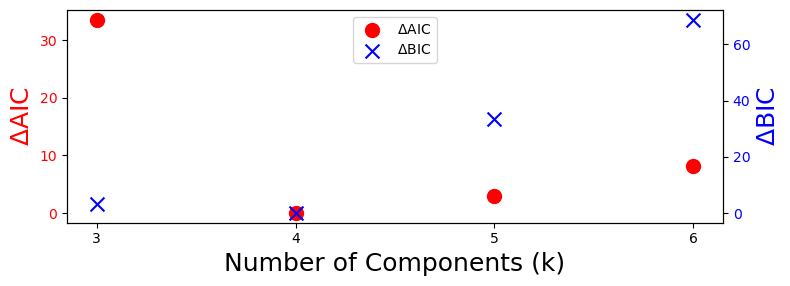

(<Figure size 800x300 with 2 Axes>,
 <Axes: xlabel='Number of Components (k)', ylabel='$\\Delta\\text{AIC}$'>,
 <Axes: ylabel='$\\Delta\\text{BIC}$'>)

In [37]:
# Plotting AIC and BIC

criteria_by_k = {}
n_observations = h_obs.Integral()
for k, result in results.items():
    if k < 3:
        continue
    print(result)
    best_result_idx = np.argmin([r["nll"] for r in result])
    best_result = result[best_result_idx]
    criteria_by_k[k] = fitting.compute_information_criteria(
        best_result['nll'],
        2 * k - 1,
        n_observations,
    )

plotting.plot_information_criteria(
    criteria_by_k,
        save_as=f"{figures_cache}/dijet_model_selection.pdf" )

# Fit Comparison and Plotting

This section compares the selected exponential mixture with the conventional dijet function on the same binned dataset. The $\chi^2$ diagnostic applies a minimum-event threshold to avoid interpreting very sparse bins as Gaussian measurements. The ROOT canvas is saved separately from paper figures for interactive inspection.

In [ ]:
# Fitting
n_data = h_obs.Integral()

# Dijet Fit
dijet_model = models.Dijet(x)
dijet_fit_result = dijet_model.pdf.fitTo(dijet_data, ROOT.RooFit.Save(), *fit_options)
print("Dijet Fit Results:")

dijet_nll = dijet_fit_result.minNll()
dijet_n_params = len(dijet_model.params())
dijet_aic = 2 * dijet_n_params + 2 * dijet_nll
dijet_bic = dijet_n_params * np.log(n_data) + 2 * dijet_nll

print(f"Dijet Fit: nll={dijet_nll:.2f}, AIC={dijet_aic:.2f}, BIC={dijet_bic:.2f}")
dijet_chi2 = fitting.chi2(
    x,
    h_obs,
    dijet_model,
    min_events=30,
    print_chi2=True,
)

# Exponential Mixture Model Fit
# fit_options.append(ROOT.RooFit.Strategy(2))
k = 4
expmix_n_params = 2 * k - 1
expmix = models.ExponentialMixtureModel(x, k, data_mean=dijet_data.mean(x))
fit_results = results[k]
best_fit_result = min(fit_results, key=lambda res: res["nll"])

best_fit_pars = best_fit_result['final_pars']
expmix.set_params(best_fit_pars)

expmix_nll = best_fit_result['nll']
expmix_aic = 2 * expmix_n_params + 2 * expmix_nll
expmix_bic = expmix_n_params * np.log(n_data) + 2 * expmix_nll

print(f"Exponential Mixture Model k={k} Fit Results: nll={expmix_nll:.2f}, AIC={expmix_aic:.2f}, BIC={expmix_bic:.2f}")
expmix_chi2 = fitting.chi2(
    x,
    h_obs,
    expmix,
    min_events=30,
    print_chi2=True,
)

model_results = [
    {
        'label': 'Dijet Function',
        'chi2': dijet_chi2['chi2'],
        'ndf': dijet_chi2['ndf'],
        'chi2_ndf': dijet_chi2['chi2_ndf'],
        'aic': dijet_aic,
        'bic': dijet_bic,
    },
    {
        'label': 'Exponential Mixture',
        'chi2': expmix_chi2['chi2'],
        'ndf': expmix_chi2['ndf'],
        'chi2_ndf': expmix_chi2['chi2_ndf'],
        'aic': expmix_aic,
        'bic': expmix_bic,
    },
]
print(fitting.format_paper_comparison_table(model_results))

Dijet Fit Results:
Dijet Fit: nll=186084288.13, AIC=372168582.25, BIC=372168627.76
chi2=95.78, ndf=74, chi2/ndf=1.294, 
Exponential Mixture Model k=4 Fit Results: nll=186084283.79, AIC=372168581.59, BIC=372168687.77
chi2=89.20, ndf=70, chi2/ndf=1.274, 
Model: ExponentialMixture-4
raw_rate_0: 2.484013860346011 + -1.0 1.0
raw_rate_1: 0.5191861260933153 + -1.0 1.0
raw_rate_2: 1.475171879528613 + -1.0 1.0
raw_rate_3: 0.887133356622545 + -1.0 1.0
_raw_weight_1: 0.7276511507714578 + -1.0 1.0
_raw_weight_2: 2.039784302882533 + -1.0 1.0
_raw_weight_3: 2.1716238326974513 + -1.0 1.0
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator Roo

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)


Info in <TCanvas::SaveAs>: ROOT file dijet_fit_comparison.root has been created


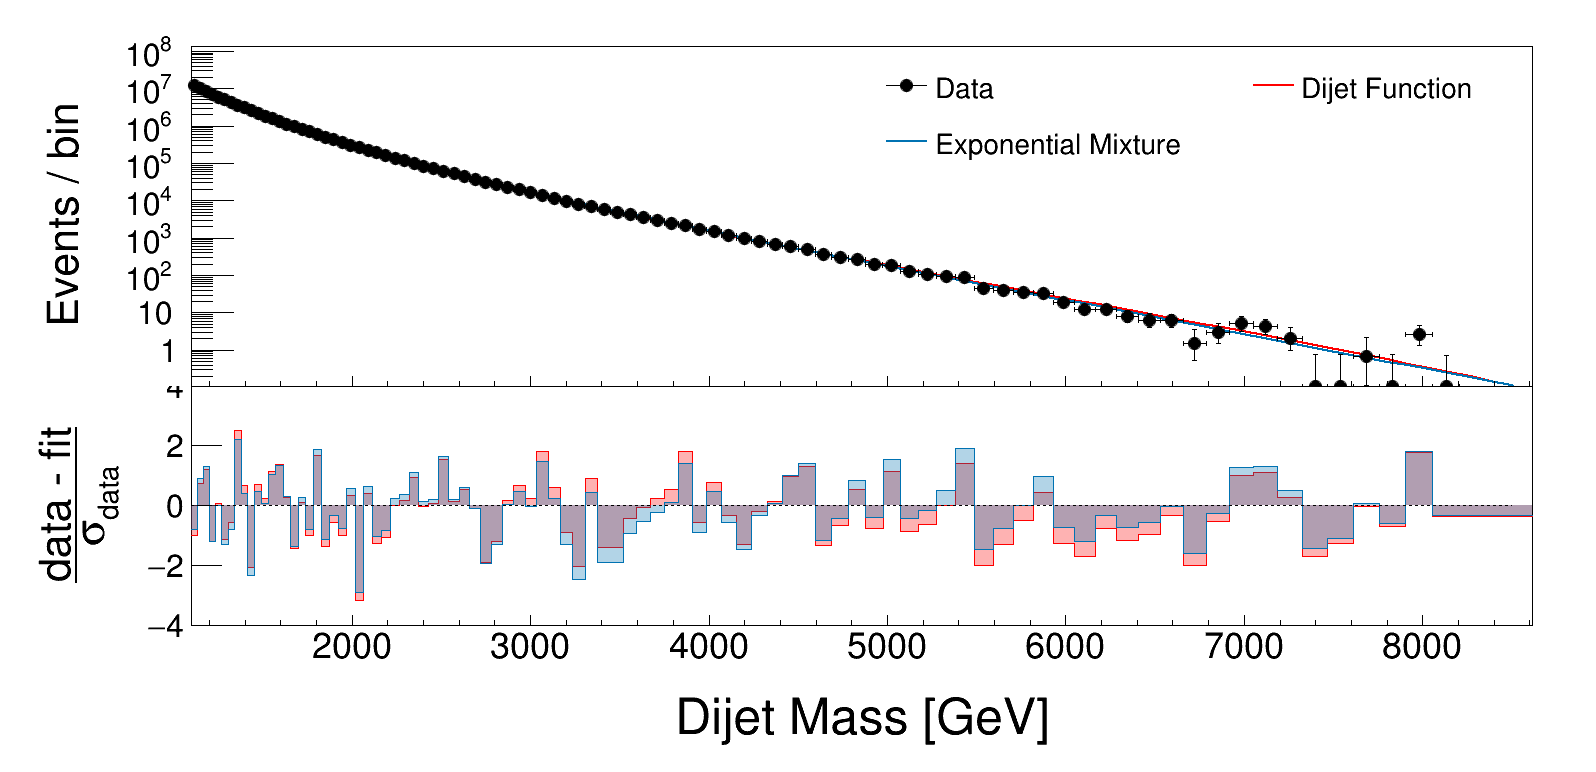

In [35]:
# Plotting
models = [
    # pdf_fit,
    dijet_model.pdf,
    expmix.pdf,
    # gpd_model.pdf,
]
model_labels = [
    # "SW Dijet Fit",
    "Dijet Function",
    f"Exponential Mixture",
    # "f_{GPD}",
    ]
model_colors = [
    ROOT.kRed,
    plotting.default_root_colors[4],
]
model_linestyles = [
    "dashed",
    "solid",
]

c = plotting.plot_fits(
    dijet_data, x, models,
    labels=model_labels,
    colors=model_colors,
    # linestyles=model_linestyles,
    # logx=True,
    # legend_bounds=(0.4, 0.56, 0.95, 0.85),
    plot_range=(x.getMin(), 8500),
    legend_text_size=0.08,
    legend_columns=2,
    # pull_range=(-20,20)
    )

# Save canvas as ROOT file
output_root_file = "dijet_fit_comparison.root"
c.SaveAs(output_root_file)